# Exercise 1 - Two level system

The purpose of this exercise is to introduce you to Julia and Jupyter notebooks and to demonstrate how you can use Julia to simulate a simple quantum system.
No programming knowlegde is required to run this example.

## Physical background

In this exercise we simulate the interaction of a two-level-system with a laser pulse.

The Hamiltonian of the two-level-system is defined as
$$
H = H_0 + H_1(t)
\;,
$$
where $H_0$ is the time-independent Hamiltonion of the system and $H_1(t)=E(t) \, V$ describes the interaction with the field $E(t)$.

Choosing the eigenstates of $H_0$ as a basis, $\{|0\rangle, |1\rangle\}$, we can represent the system Hamiltonian by
$$
H_0 = -\frac{\omega}{2}
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$
and the interaction matrix $V$ by
$$
V = -\mu_{01}
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\;.
$$
Here, $\omega>0$ is the energy splitting between the two levels and $\mu_{01}$ is the transition matrix element.

## Selected Julia packages

Matrices and vectors are a central part of Julia. This includes basic linear algebra, with more advanced features available in the `LinearAlgebra` standard library module. The [`DifferentialEquations.jl`](https://docs.sciml.ai/DiffEqDocs/stable/) package (or its sub-package `OrdinaryDiffEq`) is the go-to solution for solving any kind of differential equation.

The Julia package [`Plots.jl`](https://docs.juliaplots.org/latest/) is the standard package for 2D data visualisation. It closely resembles the plotting syntax from Matlab.

[`QuantumControl.jl`](https://juliaquantumcontrol.github.io/QuantumControl.jl/stable/) is a package for formulating and solving quantum control problems, with the [`QuantumPropagators.jl`](https://juliaquantumcontrol.github.io/QuantumPropagators.jl/stable/) sub-package providing an interface to simulate time dynamics. We will use this package here as it provides a convenient interface that is specific to quantum dynamics. It wraps `DifferentialEquation`/`OrdinaryDiffEq`, although it also implements its own methods specifically for piecewise-constant dynamics, which we will use in later examples.

## How to use this notebook

*You can evaluate all cells marked with `[n]:` by* **selecting it and hitting SHIFT+ENTER** *or the play button in the top panel.*

Just go through the notebook and evaluate the cells one after another. You can also change the cell to play around with the values and reevaluate it. If you do so, make sure to evaluate all the cells that rely on the one you changed. Have fun!

## Let's start!

First we need to load the Julia packages that we are going to use in the following:

In [1]:
using Plots
using QuantumPropagators
using OrdinaryDiffEq

We'll also set some defaults for `Plots`, like increasing the default line width for better readability.

In [2]:
Plots.default(
    linewidth               = 2.0,
    foreground_color_legend = nothing,
    background_color_legend = RGBA(1, 1, 1, 0.8)
)

We start with defining the time interval for the propagation. For numerical calculations, we need to represent the time interval by a grid with a finite amount of grid points.

Let the time grid start at `t_start=0` and end at `t_stop=50` with a total amount of `Nt=10000` grid points. We can create such a grid with the built-in `range` function, in combination with `collect` to create an explicit vector:

In [3]:
t_start = 0
t_stop = 50
Nt = 10000
t = collect(range(t_start, t_stop; length=Nt));

## The model

Now we need to define the individual parts of the Hamiltonian. For the simulation use the following parameters:

In [4]:
ω = 10.0;
μ₀₁ = 1.0;

Note that Julia encourages the use of Unicode symbols. You can type these with, e.g. `\omega<tab>` and `\mu<tab>\_0<tab>\_<tab>`. If you are unsure how to type a particular unicode character, paste it into Julia's help (accessed by a `?` at the beginning of a cell):

In [5]:
? Ψ̃

"Ψ̃" can be typed by \Psi<tab>\tilde<tab>

search:

Couldn't find Ψ̃
Perhaps you meant In, Nt, t, ω, GR, KW, gr, !, !=, %, &, ', *, +, -, /, // or :


No documentation found.

Binding `Ψ̃` does not exist.


We need the matrix for the time independent Hamiltonian $H_0$ ...

In [6]:
H₀ = -ω/2 * [
    1   0
    0  -1
]

2×2 Matrix{Float64}:
 -5.0  -0.0
 -0.0   5.0

... and the interaction matrix $V$:

In [7]:
V = -μ₀₁ * [
     0  1
     1  0
]

2×2 Matrix{Float64}:
 -0.0  -1.0
 -1.0  -0.0

Next, we need to define the electric field `E` on the time grid `t`.

We assume a Gaussian shaped pulse,
$$
E(t) = E_0 \, e^{-(t-t_0)^2 / (2 \tau^2)} \, \cos(w_l (t-t_0) + \phi)
$$
with the following parameters: $\omega_l=\omega$, $\phi=0$, $E_0=0.2$ and $t_0=25$. 

Choose a value for the pulse duration $\tau$. The duration should not be larger than $7.5$, in order to fit completly into our time grid.

In [8]:
t₀ = 25.0
ωₗ = ω
E₀ = 0.2
ϕ = 0
τ = 2.5

E(t) = E₀ * cos(ωₗ * (t - t₀) + ϕ) * exp(- (t - t₀)^2 / (2τ^2));

Now we collect everything together and assemble the total Hamiltonian of our system. This is where the `QuantumPropagtors` package becomes useful, as it provides a function `hamiltonian` to construct a time-dependent object that will be suitable for the `QuantumPropagators.propagate` function later on:

In [9]:
H = hamiltonian(H₀, (V, E))

Generator with 2 ops and 1 amplitudes
 ops::Vector{Matrix{Float64}}:
  [-5.0 -0.0; -0.0 5.0]
  [-0.0 -1.0; -1.0 -0.0]
 amplitudes::Vector{typeof(E)}:
  E


As a last step in setting up the model, we define the two states.

In [10]:
Ψ₀ = ComplexF64[1, 0] # State |0⟩

2-element Vector{ComplexF64}:
 1.0 + 0.0im
 0.0 + 0.0im

It is critically important to ensure that `Ψ₀` is a complex vector. If we had just written `Ψ₀ = [1, 0]`, Julia would have inferred it as an array of integers, which is not the correct domain for a quantum state.

In [11]:
Ψ₁ = ComplexF64[0, 1] # State |1⟩

2-element Vector{ComplexF64}:
 0.0 + 0.0im
 1.0 + 0.0im

## Propagation and results

Before we can start with the propagation, we first need to define the observables that we are interested in. For the present case, we are interested in the population dynamics. To track the population of the two levels, we define the projectors $\hat{P}_{i} =
|i\rangle\langle i|$.

In [12]:
P₀ = Ψ₀ * Ψ₀'

2×2 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

Note that Julia uses `'` for the complex conjugate (what we would write as a dagger on paper)

In [13]:
P₁ = Ψ₁ * Ψ₁'

2×2 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im

Having them set up, we can use the `propagate` function provided by the `QuantumPropagators` package to obtain the dynamics over time. We delegate solving the Schrödinger equation to the `OrdinaryDiffEq` package by passing it as `method`l

As the initial state of our simulation we choose the ground state, $|0\rangle$. With `storage=true`, we specify that we would like `propagate` to return an array of the expectation values for the `observables` $P_0$, $P_1$, i.e., the population in the states $|0\rangle$, $|1\rangle$. Without `storage=true`, `propagate` would only return the final state.

In [14]:
output = propagate(Ψ₀, H, t; method=OrdinaryDiffEq, observables=[P₀, P₁], storage=true)

2×10000 Matrix{ComplexF64}:
 1.0+0.0im          1.0+0.0im  …  0.656097+0.0im  0.656097+0.0im
 0.0+0.0im  1.77971e-51+0.0im     0.343903+0.0im  0.343903+0.0im

Now let's plot the population dynamics:

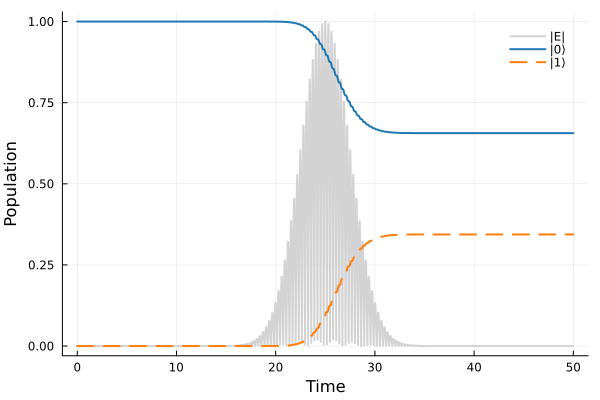

In [15]:
E_max = maximum(abs.(E.(t)))
plot(t, abs.(E.(t)) / E_max; color="lightgray", label="|E|")
plot!(t, real.(output[1,:]); color="#1f77b4", label="|0⟩")
plot!(t, real.(output[2,:]); color="#ff7f0e", linestyle=:dash, label="|1⟩")
plot!(; xlabel="Time", ylabel="Population")

Play with the pulse parameters and observe how this affects the population dynamics. Can you find a combination of parameters that produce a complete population inversion? What do you need to obtain a full Rabi cycle? What happens if you change the frequency of the laser pulse?